In [1]:
"""
Model Result Interpretation for Multiclass TE Classification

This notebook provides tools for interpreting results from the multiclass 
classification model (vgp_features_tpase_multiclass.ipynb).

Key analyses:
1. Confusion Matrix - Visualize how well the model classifies each class
2. Confidence Analysis - Use prediction probabilities to detect potentially 
   misclassified sequences
3. Disagreement Analysis - Find sequences where model prediction differs from 
   feature-based labels

Requirements:
- Trained model checkpoint (improved_rc_cnn_best.pt)
- Evaluation results CSV with columns: header, true_label, predicted_label, 
  confidence, probabilities
"""

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Imports loaded successfully!")

Imports loaded successfully!


## Configuration & Data Paths

Set up paths to the model checkpoint and data files.

In [2]:
# ============ Configuration ============
# Paths relative to this notebook location
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data" / "vgp"
MODEL_DIR = BASE_DIR / "data_analysis" / "vgp_model_data_tpase_multi"

# Data files
FASTA_PATH = DATA_DIR / "all_vgp_tes.fa"
LABEL_PATH = DATA_DIR / "features-tpase"  # Model-based labels
MODEL_CKPT = MODEL_DIR / "improved_rc_cnn_best.pt"

# Fixed canvas length (must match training)
FIXED_LENGTH = 25565

# Verify paths
print("Checking paths...")
for name, path in [("FASTA", FASTA_PATH), ("Labels", LABEL_PATH), ("Model", MODEL_CKPT)]:
    status = "✓" if path.exists() else "✗ NOT FOUND"
    print(f"  {name}: {status} ({path})")

# Flag missing files
MISSING_FILES = []
if not FASTA_PATH.exists():
    MISSING_FILES.append("FASTA file")
if not LABEL_PATH.exists():
    MISSING_FILES.append("Labels file")
if not MODEL_CKPT.exists():
    MISSING_FILES.append("Model checkpoint")

if MISSING_FILES:
    print(f"\n⚠️  Missing files: {', '.join(MISSING_FILES)}")
    print("Please run the training notebook first to generate the model checkpoint.")

Checking paths...
  FASTA: ✓ (/Users/alexyang/Documents/Part III System Biology/TE Classification/data/vgp/all_vgp_tes.fa)
  Labels: ✓ (/Users/alexyang/Documents/Part III System Biology/TE Classification/data/vgp/features-tpase)
  Model: ✓ (/Users/alexyang/Documents/Part III System Biology/TE Classification/data_analysis/vgp_model_data_tpase_multi/improved_rc_cnn_best.pt)


## Data Loading Utilities

Functions to read FASTA files and parse labels.

In [3]:
# ============ Data Loading Functions ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line: 
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
            
    return headers, sequences

def load_multiclass_labels(label_path):
    """
    Parse a label file into a dict: header -> tag (string).
    Expected format: >header\ttag [other columns ignored]
    """
    d = {}
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            d[header] = tag
    return d

def parse_original_label_from_header(header):
    """
    Extract the original TE family label from the FASTA header.
    Header format: NAME#LABEL (e.g., 'hAT_1-aAnoBae#DNA/hAT')
    Returns the label after '#' (e.g., 'DNA/hAT') or None if not found.
    """
    if '#' in header:
        return header.split('#')[-1]
    return None

print("Data loading functions defined.")

Data loading functions defined.


## Model Architecture

Define the network architecture to load the trained checkpoint.

In [4]:
# ============ Encoding and Device ============
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)

def resolve_device(requested=None):
    """Return the best available accelerator."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

# ============ Network Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)

class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p

def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)

class RCFirstConv1d(nn.Module):
    """RC-invariant first convolution layer."""
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return y

# ============ Main Model ============

class ImprovedRCCNN(nn.Module):
    """Improved RC-invariant CNN for multi-class TE classification."""
    def __init__(
        self,
        num_classes,
        width=128,
        motif_kernels=(7, 15, 21),
        context_kernel=9,
        context_dilations=(1, 2, 4, 8),
        dropout=0.15,
        rc_mode="late",
        aux_weight=0.1
    ):
        super().__init__()
        self.num_classes = int(num_classes)
        self.rc_mode = rc_mode
        self.aux_weight = aux_weight
        
        if rc_mode == "early":
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k//2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)
        
        self.class_head = nn.Sequential(
            nn.Linear(width, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, self.num_classes),
        )
        
        self.boundary_head = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 3),
            nn.Sigmoid()
        )
        
    @staticmethod
    def rc_transform(x, mask):
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc
    
    def encode(self, x, mask):
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        return masked_avg_pool(z, m)
    
    def forward(self, x, mask):
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            pooled = 0.5 * (f + r)
        else:
            pooled = self.encode(x, mask)
        
        class_logits = self.class_head(pooled)
        boundary_pred = self.boundary_head(pooled)
        return class_logits, boundary_pred

print("Model architecture defined.")

Model architecture defined.


## Dataset and Inference

Set up the dataset for inference and load the trained model.

In [5]:
# ============ Dataset for Inference ============

class SeqDatasetInference(Dataset):
    """Dataset for inference with center placement (deterministic)."""
    def __init__(self, headers, sequences, label_ids=None, fixed_length=FIXED_LENGTH):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.label_ids = label_ids if label_ids is not None else [0] * len(headers)
        self.fixed_length = fixed_length
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)
        
        seq_bytes = seq.encode("ascii", "ignore")
        seq_idx = ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]
        
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = max_start // 2  # Center placement
        end_pos = start_pos + seq_len
        
        return (
            self.headers[idx],
            seq_idx,
            int(self.label_ids[idx]),
            start_pos,
            end_pos,
            seq_len
        )

def collate_inference(batch, fixed_length=FIXED_LENGTH):
    """Collate function for inference."""
    headers, seq_idxs, labels, starts, ends, lengths = zip(*batch)
    
    B = len(batch)
    X = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)
    
    for i, (seq_idx, start, end, seq_len) in enumerate(zip(seq_idxs, starts, ends, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)
    
    Y = torch.tensor(labels, dtype=torch.long)
    return list(headers), X, mask, Y

# ============ Load Model ============

def load_model_from_checkpoint(ckpt_path, device):
    """Load model from checkpoint."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    
    class_names = ckpt['class_names']
    tag_to_id = ckpt['tag_to_id']
    arch = ckpt['arch']
    
    model = ImprovedRCCNN(
        num_classes=len(class_names),
        width=arch.get('width', 128),
        motif_kernels=arch.get('motif_kernels', (7, 15, 21)),
        context_kernel=arch.get('context_kernel', 9),
        context_dilations=arch.get('context_dilations', (1, 2, 4, 8)),
        rc_mode=arch.get('rc_mode', 'late'),
    ).to(device)
    
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    
    return model, class_names, tag_to_id

print("Dataset and model loading functions defined.")

Dataset and model loading functions defined.


## Load Data and Run Full Inference

Load the FASTA data, labels, and run the model on ALL sequences to get predictions and confidence scores.

In [6]:
from tqdm.auto import tqdm

# ============ Load Data ============
print("Loading FASTA data...")
headers, sequences = read_fasta(FASTA_PATH)
print(f"  Loaded {len(headers)} sequences")

print("\nLoading model labels (feature-based TPase labels)...")
model_labels = load_multiclass_labels(LABEL_PATH)
print(f"  Loaded {len(model_labels)} labels")

# Extract original labels from headers
print("\nExtracting original labels from headers...")
original_labels = {h: parse_original_label_from_header(h) for h in headers}

# Filter to sequences that have model labels
headers_filtered = []
sequences_filtered = []
tags_filtered = []
original_filtered = []

for h, s in zip(headers, sequences):
    if h in model_labels:
        headers_filtered.append(h)
        sequences_filtered.append(s)
        tags_filtered.append(model_labels[h])
        original_filtered.append(original_labels.get(h, "Unknown"))

print(f"  Filtered to {len(headers_filtered)} sequences with model labels")

# Show class distribution
tag_counts = Counter(tags_filtered)
print(f"\nClass distribution ({len(tag_counts)} classes):")
for tag, count in sorted(tag_counts.items(), key=lambda x: -x[1])[:15]:
    print(f"  {tag}: {count}")
if len(tag_counts) > 15:
    print(f"  ... and {len(tag_counts) - 15} more classes")

Loading FASTA data...
  Loaded 135751 sequences

Loading model labels (feature-based TPase labels)...
  Loaded 135751 labels

Extracting original labels from headers...
  Filtered to 135751 sequences with model labels

Class distribution (18 classes):
  None: 125101
  DNA/hAT: 4900
  DNA/TcMar-Tc1: 1875
  DNA: 1530
  DNA/PIF-Harbinger: 790
  DNA/PiggyBac: 563
  DNA/Academ-1: 415
  DNA/CMC: 180
  DNA/Sola-2: 93
  DNA/Kolobok: 86
  DNA/P: 77
  DNA/Sola-1: 43
  DNA/PIF-ISL2EU: 38
  DNA/MULE-MuDR: 23
  DNA/Crypton-V: 19
  ... and 3 more classes


In [8]:
# ============ Load Model and Run Inference ============
device = resolve_device()
print(f"Using device: {device}")

# Load model
print("\nLoading model checkpoint...")
model, class_names, tag_to_id = load_model_from_checkpoint(MODEL_CKPT, device)
id_to_tag = {v: k for k, v in tag_to_id.items()}
print(f"  Model loaded with {len(class_names)} classes: {class_names}")

# Filter data to only include classes the model knows about
print("\nFiltering to classes in model...")
valid_indices = [i for i, t in enumerate(tags_filtered) if t in tag_to_id]
print(f"  {len(valid_indices)} sequences have labels in model's class set")

headers_valid = [headers_filtered[i] for i in valid_indices]
sequences_valid = [sequences_filtered[i] for i in valid_indices]
tags_valid = [tags_filtered[i] for i in valid_indices]
original_valid = [original_filtered[i] for i in valid_indices]
label_ids = [tag_to_id[t] for t in tags_valid]

# ============ Subset for faster analysis (optional) ============
# Set to None to run on full dataset
SUBSET_SIZE = 10000  # Use a subset for faster demonstration

if SUBSET_SIZE is not None and SUBSET_SIZE < len(headers_valid):
    print(f"\n⚠️  Using subset of {SUBSET_SIZE} samples for faster analysis")
    print("   Set SUBSET_SIZE = None above to run on full dataset")
    
    # Stratified subsample
    rng = np.random.default_rng(42)
    class_indices = {c: [] for c in range(len(class_names))}
    for i, y in enumerate(label_ids):
        class_indices[y].append(i)
    
    selected = []
    for c in range(len(class_names)):
        c_idx = np.array(class_indices[c])
        n_samples = max(1, int(len(c_idx) / len(label_ids) * SUBSET_SIZE))
        n_samples = min(n_samples, len(c_idx))
        sel = rng.choice(c_idx, size=n_samples, replace=False)
        selected.extend(sel)
    
    selected = sorted(selected)
    headers_valid = [headers_valid[i] for i in selected]
    sequences_valid = [sequences_valid[i] for i in selected]
    tags_valid = [tags_valid[i] for i in selected]
    original_valid = [original_valid[i] for i in selected]
    label_ids = [label_ids[i] for i in selected]
    print(f"   Subset size: {len(headers_valid)}")

# Create dataset
dataset = SeqDatasetInference(headers_valid, sequences_valid, label_ids, fixed_length=FIXED_LENGTH)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0, collate_fn=collate_inference)

# Run inference
print("\nRunning inference...")
all_headers = []
all_logits = []
all_true_labels = []

model.eval()
with torch.no_grad():
    for batch_headers, X, mask, Y in tqdm(loader, desc="Inference"):
        X = X.to(device)
        mask = mask.to(device)
        
        logits, _ = model(X, mask)
        
        all_headers.extend(batch_headers)
        all_logits.append(logits.cpu())
        all_true_labels.append(Y)

# Concatenate results
logits_tensor = torch.cat(all_logits, dim=0)
true_labels_tensor = torch.cat(all_true_labels, dim=0)

# Convert to numpy
logits_np = logits_tensor.numpy()
true_labels_np = true_labels_tensor.numpy()

# Compute probabilities and predictions
probs_np = torch.softmax(logits_tensor, dim=1).numpy()
pred_labels_np = logits_np.argmax(axis=1)
max_probs = probs_np.max(axis=1)  # Confidence score

print(f"\n✓ Inference complete on {len(all_headers)} sequences")

Using device: mps

Loading model checkpoint...
  Model loaded with 11 classes: ['None', 'DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/Kolobok', 'DNA/P', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/Sola-2', 'DNA/TcMar-Tc1', 'DNA/hAT']

Filtering to classes in model...
  135610 sequences have labels in model's class set

⚠️  Using subset of 10000 samples for faster analysis
   Set SUBSET_SIZE = None above to run on full dataset
   Subset size: 9995

Running inference...


Inference:   0%|          | 0/157 [00:00<?, ?it/s]


✓ Inference complete on 9995 sequences


## 1. Confusion Matrix

The **confusion matrix** shows how well the model classifies each class:
- Rows = True labels (what the sequence actually is)
- Columns = Predicted labels (what the model predicted)
- Diagonal = Correct predictions
- Off-diagonal = Misclassifications

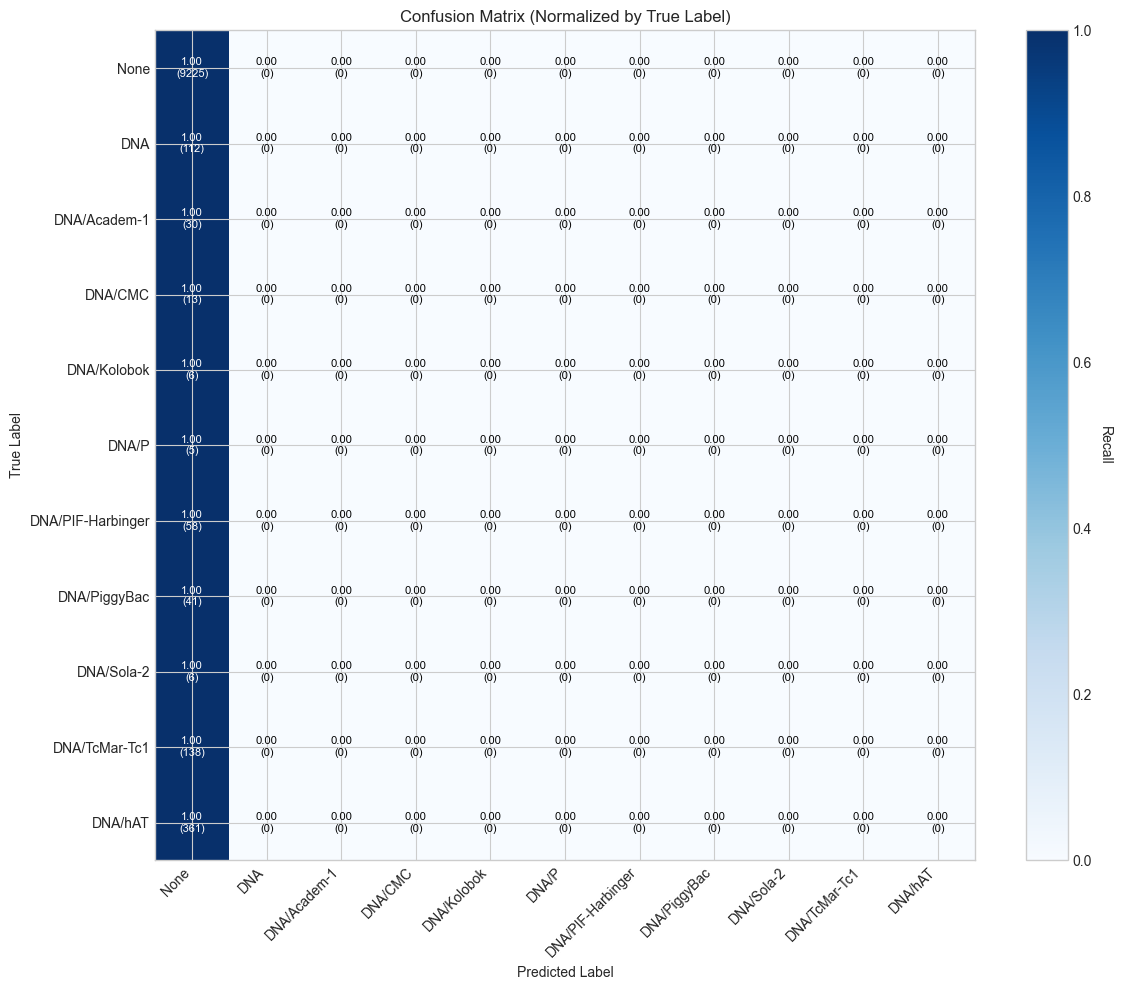


CLASSIFICATION METRICS

Accuracy: 0.9230
Balanced Accuracy: 0.0909
Macro F1: 0.0873
Weighted F1: 0.8860


In [9]:
# ============ Confusion Matrix ============

def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True, figsize=(12, 10)):
    """
    Plot a confusion matrix with nice formatting.
    
    Args:
        y_true: True labels (numeric)
        y_pred: Predicted labels (numeric)
        class_names: List of class names
        normalize: If True, normalize by row (true label) to show recall per class
        figsize: Figure size
    """
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    
    if normalize:
        # Normalize by row (each row sums to 1)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)  # Handle division by zero
        display_cm = cm_norm
        fmt = '.2f'
        title = 'Confusion Matrix (Normalized by True Label)'
        cbar_label = 'Recall'
    else:
        display_cm = cm
        fmt = 'd'
        title = 'Confusion Matrix (Raw Counts)'
        cbar_label = 'Count'
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.imshow(display_cm, cmap='Blues', aspect='auto')
    
    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbar_label, rotation=-90, va="bottom")
    
    # Set ticks and labels
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    
    # Add text annotations
    thresh = display_cm.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = display_cm[i, j]
            if normalize:
                text = f'{value:.2f}\n({cm[i,j]})'
            else:
                text = f'{value}'
            color = 'white' if value > thresh else 'black'
            ax.text(j, i, text, ha='center', va='center', color=color, fontsize=8)
    
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    
    fig.tight_layout()
    return fig, ax, cm

# Generate confusion matrix
fig, ax, cm = plot_confusion_matrix(true_labels_np, pred_labels_np, class_names, normalize=True)
plt.show()

# Print summary metrics
print("\n" + "="*60)
print("CLASSIFICATION METRICS")
print("="*60)
print(f"\nAccuracy: {accuracy_score(true_labels_np, pred_labels_np):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(true_labels_np, pred_labels_np):.4f}")
print(f"Macro F1: {f1_score(true_labels_np, pred_labels_np, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(true_labels_np, pred_labels_np, average='weighted'):.4f}")


PER-CLASS CLASSIFICATION REPORT
                   precision    recall  f1-score   support

             None       0.92      1.00      0.96      9225
              DNA       0.00      0.00      0.00       112
     DNA/Academ-1       0.00      0.00      0.00        30
          DNA/CMC       0.00      0.00      0.00        13
      DNA/Kolobok       0.00      0.00      0.00         6
            DNA/P       0.00      0.00      0.00         5
DNA/PIF-Harbinger       0.00      0.00      0.00        58
     DNA/PiggyBac       0.00      0.00      0.00        41
       DNA/Sola-2       0.00      0.00      0.00         6
    DNA/TcMar-Tc1       0.00      0.00      0.00       138
          DNA/hAT       0.00      0.00      0.00       361

         accuracy                           0.92      9995
        macro avg       0.08      0.09      0.09      9995
     weighted avg       0.85      0.92      0.89      9995



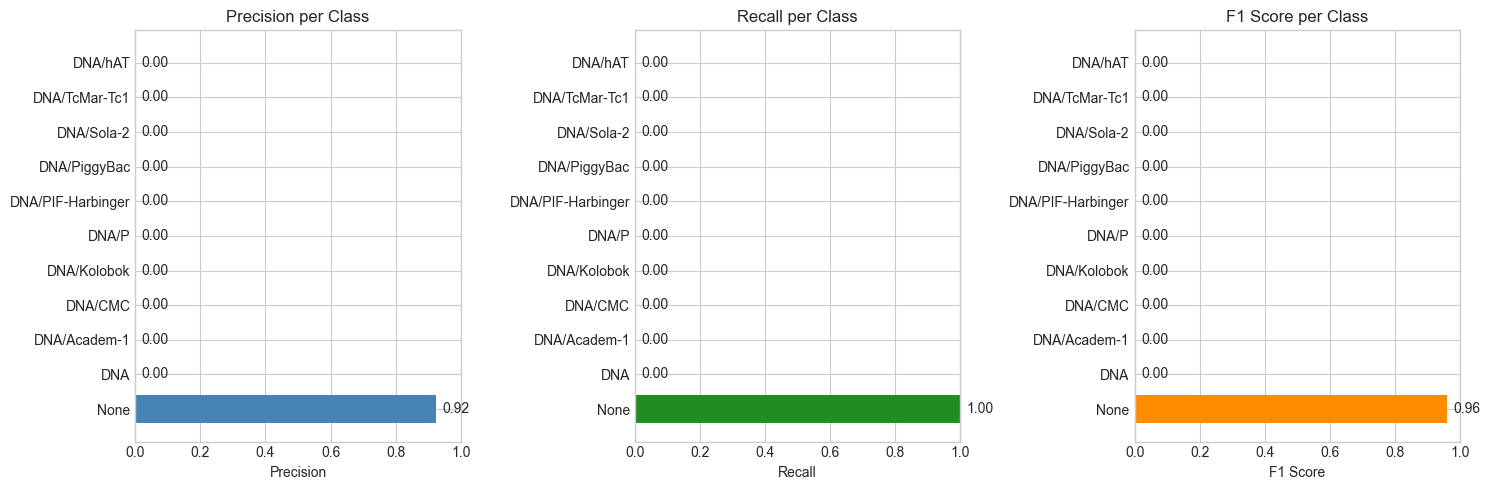

In [10]:
# ============ Per-Class Classification Report ============
print("\n" + "="*60)
print("PER-CLASS CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    true_labels_np, 
    pred_labels_np, 
    target_names=class_names, 
    zero_division=0
))

# Per-class metrics visualization
def plot_per_class_metrics(y_true, y_pred, class_names):
    """Plot per-class precision, recall, and F1 scores."""
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    x = np.arange(len(class_names))
    
    # Precision
    axes[0].barh(x, precision, color='steelblue')
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(class_names)
    axes[0].set_xlabel('Precision')
    axes[0].set_title('Precision per Class')
    axes[0].set_xlim(0, 1)
    for i, v in enumerate(precision):
        axes[0].text(v + 0.02, i, f'{v:.2f}', va='center')
    
    # Recall
    axes[1].barh(x, recall, color='forestgreen')
    axes[1].set_yticks(x)
    axes[1].set_yticklabels(class_names)
    axes[1].set_xlabel('Recall')
    axes[1].set_title('Recall per Class')
    axes[1].set_xlim(0, 1)
    for i, v in enumerate(recall):
        axes[1].text(v + 0.02, i, f'{v:.2f}', va='center')
    
    # F1
    axes[2].barh(x, f1, color='darkorange')
    axes[2].set_yticks(x)
    axes[2].set_yticklabels(class_names)
    axes[2].set_xlabel('F1 Score')
    axes[2].set_title('F1 Score per Class')
    axes[2].set_xlim(0, 1)
    for i, v in enumerate(f1):
        axes[2].text(v + 0.02, i, f'{v:.2f}', va='center')
    
    fig.tight_layout()
    return fig, axes

fig, axes = plot_per_class_metrics(true_labels_np, pred_labels_np, class_names)
plt.show()

## 2. Confidence Analysis

The model outputs logits that can be converted to probabilities using softmax. 
The **maximum probability** for each prediction represents the model's **confidence**.

Low confidence predictions are more likely to be misclassified and can be flagged for manual review.

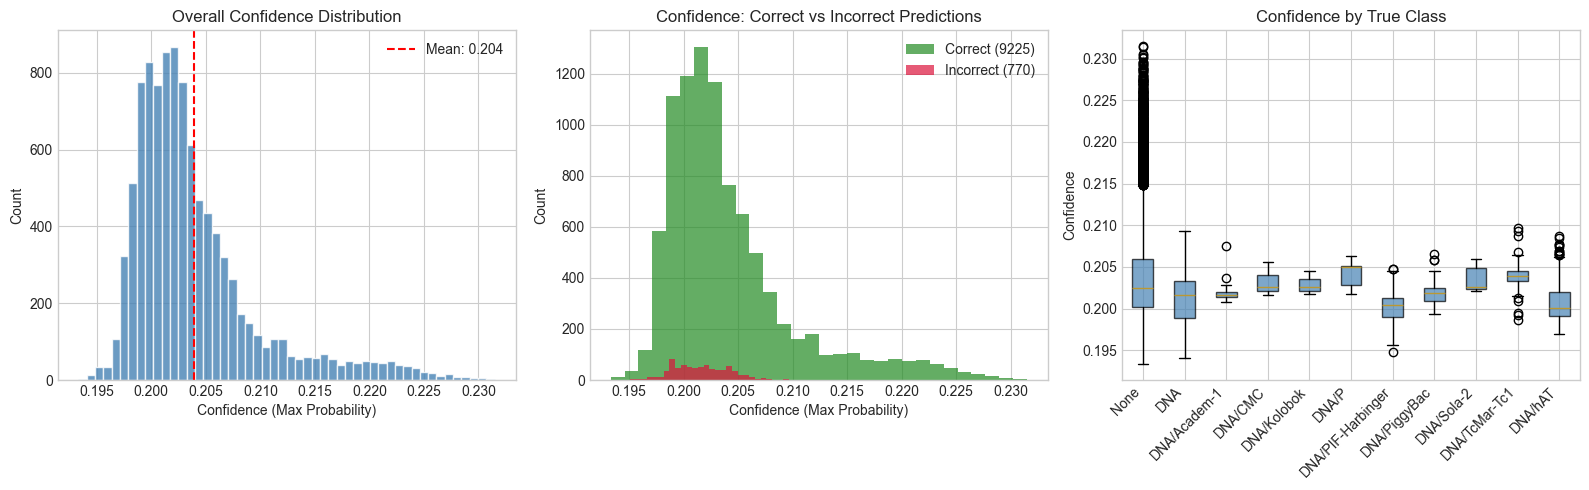


CONFIDENCE STATISTICS

Overall confidence:
  Mean: 0.2039
  Std:  0.0058
  Min:  0.1933
  Max:  0.2315

Correct predictions (9225):
  Mean confidence: 0.2041

Incorrect predictions (770):
  Mean confidence: 0.2016


In [11]:
# ============ Confidence Score Distribution ============

def plot_confidence_distribution(max_probs, true_labels, pred_labels, class_names):
    """
    Plot confidence score distributions.
    
    Shows:
    1. Overall confidence distribution
    2. Confidence distribution for correct vs incorrect predictions
    3. Confidence distribution by true class
    """
    correct_mask = true_labels == pred_labels
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 1. Overall confidence distribution
    axes[0].hist(max_probs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(max_probs.mean(), color='red', linestyle='--', label=f'Mean: {max_probs.mean():.3f}')
    axes[0].set_xlabel('Confidence (Max Probability)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Overall Confidence Distribution')
    axes[0].legend()
    
    # 2. Correct vs Incorrect
    if correct_mask.sum() > 0:
        axes[1].hist(max_probs[correct_mask], bins=30, alpha=0.7, 
                     label=f'Correct ({correct_mask.sum()})', color='forestgreen')
    if (~correct_mask).sum() > 0:
        axes[1].hist(max_probs[~correct_mask], bins=30, alpha=0.7, 
                     label=f'Incorrect ({(~correct_mask).sum()})', color='crimson')
    axes[1].set_xlabel('Confidence (Max Probability)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Confidence: Correct vs Incorrect Predictions')
    axes[1].legend()
    
    # 3. Confidence by true class (boxplot)
    conf_by_class = [max_probs[true_labels == i] for i in range(len(class_names))]
    # Filter out empty arrays
    valid_classes = [(class_names[i], conf_by_class[i]) for i in range(len(class_names)) 
                     if len(conf_by_class[i]) > 0]
    if valid_classes:
        names, data = zip(*valid_classes)
        bp = axes[2].boxplot(data, vert=True, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('steelblue')
            patch.set_alpha(0.7)
        axes[2].set_xticklabels(names, rotation=45, ha='right')
        axes[2].set_ylabel('Confidence')
        axes[2].set_title('Confidence by True Class')
    
    fig.tight_layout()
    return fig, axes

fig, axes = plot_confidence_distribution(max_probs, true_labels_np, pred_labels_np, class_names)
plt.show()

# Summary statistics
print("\n" + "="*60)
print("CONFIDENCE STATISTICS")
print("="*60)
print(f"\nOverall confidence:")
print(f"  Mean: {max_probs.mean():.4f}")
print(f"  Std:  {max_probs.std():.4f}")
print(f"  Min:  {max_probs.min():.4f}")
print(f"  Max:  {max_probs.max():.4f}")

correct_mask = true_labels_np == pred_labels_np
if correct_mask.sum() > 0:
    print(f"\nCorrect predictions ({correct_mask.sum()}):")
    print(f"  Mean confidence: {max_probs[correct_mask].mean():.4f}")
if (~correct_mask).sum() > 0:
    print(f"\nIncorrect predictions ({(~correct_mask).sum()}):")
    print(f"  Mean confidence: {max_probs[~correct_mask].mean():.4f}")

## 3. Detecting Potential Misclassifications

We can use confidence scores to identify sequences that the model is unsure about. 
These are candidates for manual review or potential misclassifications in the training data.

**Key metrics for uncertainty:**
1. **Low max probability** - Model isn't confident in any single class
2. **High entropy** - Probability is spread across multiple classes
3. **Small margin** - The top two predictions have similar probabilities

In [12]:
# ============ Uncertainty Metrics ============

def compute_uncertainty_metrics(probs):
    """
    Compute various uncertainty metrics from probability distributions.
    
    Returns:
        max_prob: Maximum probability (confidence)
        entropy: Shannon entropy (higher = more uncertain)
        margin: Difference between top two probabilities (lower = more uncertain)
    """
    # Max probability (confidence)
    max_prob = probs.max(axis=1)
    
    # Entropy: -sum(p * log(p))
    eps = 1e-10
    entropy = -np.sum(probs * np.log(probs + eps), axis=1)
    
    # Margin: difference between top 1 and top 2
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]  # Sort descending
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]
    
    # Second best class
    sorted_indices = np.argsort(probs, axis=1)[:, ::-1]
    second_best = sorted_indices[:, 1]
    
    return max_prob, entropy, margin, second_best

max_prob, entropy, margin, second_best_labels = compute_uncertainty_metrics(probs_np)

# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'header': all_headers,
    'true_label': [id_to_tag[i] for i in true_labels_np],
    'true_label_id': true_labels_np,
    'pred_label': [id_to_tag[i] for i in pred_labels_np],
    'pred_label_id': pred_labels_np,
    'second_best_label': [id_to_tag[i] for i in second_best_labels],
    'confidence': max_prob,
    'entropy': entropy,
    'margin': margin,
    'correct': true_labels_np == pred_labels_np,
    'original_label': original_valid,  # From header (feature-based)
})

# Add all class probabilities
for i, name in enumerate(class_names):
    results_df[f'prob_{name}'] = probs_np[:, i]

print(f"Results DataFrame shape: {results_df.shape}")
print(f"\nColumns: {list(results_df.columns[:12])}...")
results_df.head()

Results DataFrame shape: (9995, 22)

Columns: ['header', 'true_label', 'true_label_id', 'pred_label', 'pred_label_id', 'second_best_label', 'confidence', 'entropy', 'margin', 'correct', 'original_label', 'prob_None']...


,header,true_label,true_label_id,pred_label,pred_label_id,second_best_label,confidence,entropy,margin,correct,...,prob_DNA,prob_DNA/Academ-1,prob_DNA/CMC,prob_DNA/Kolobok,prob_DNA/P,prob_DNA/PIF-Harbinger,prob_DNA/PiggyBac,prob_DNA/Sola-2,prob_DNA/TcMar-Tc1,prob_DNA/hAT
0,ERV1_15-aAnoBae#LTR/ERV1,None,0,None,0,DNA/P,0.200343,2.312782,0.085408,True,...,0.063292,0.077081,0.088512,0.102805,0.114936,0.053493,0.065057,0.109342,0.051663,0.073476
1,hAT_130-aAnoBae#DNA/hAT,DNA/hAT,10,None,0,DNA/P,0.198483,2.316315,0.085322,False,...,0.065816,0.077756,0.088393,0.101932,0.113161,0.053322,0.066163,0.108912,0.051819,0.074243
2,hAT_133-aAnoBae#DNA/hAT,DNA/hAT,10,None,0,DNA/P,0.198314,2.316523,0.085145,False,...,0.065914,0.077766,0.088383,0.101909,0.113169,0.053354,0.066196,0.108906,0.051843,0.074245
3,hAT_137-aAnoBae#DNA/hAT,DNA/hAT,10,None,0,DNA/P,0.198950,2.315543,0.085554,False,...,0.065096,0.077459,0.088712,0.102093,0.113396,0.053327,0.065969,0.109015,0.051909,0.074075
4,Gypsy_612-aAnoBae#LTR/Gypsy,None,0,None,0,DNA/P,0.198165,2.316955,0.085064,True,...,0.066863,0.077948,0.087861,0.101746,0.113101,0.053447,0.066457,0.108776,0.051591,0.074045


In [13]:
# ============ Identify Low-Confidence Predictions ============

def find_low_confidence_predictions(df, threshold=0.5):
    """
    Find predictions with low confidence that may be misclassified.
    
    Args:
        df: Results dataframe with 'confidence' column
        threshold: Confidence threshold (predictions below this are flagged)
    
    Returns:
        DataFrame of low-confidence predictions sorted by confidence
    """
    low_conf = df[df['confidence'] < threshold].copy()
    low_conf = low_conf.sort_values('confidence', ascending=True)
    return low_conf

# Find predictions with confidence below different thresholds
print("="*60)
print("LOW-CONFIDENCE PREDICTIONS (potential misclassifications)")
print("="*60)

# Since current model has very low confidence, use adaptive thresholds
thresholds = [0.3, 0.4, 0.5, 0.7, 0.9]
for thresh in thresholds:
    count = (results_df['confidence'] < thresh).sum()
    pct = count / len(results_df) * 100
    print(f"  Confidence < {thresh:.1f}: {count:,} sequences ({pct:.1f}%)")

# Use the 10th percentile as a threshold for "lowest confidence"
low_conf_threshold = np.percentile(results_df['confidence'], 10)
print(f"\n10th percentile confidence: {low_conf_threshold:.4f}")

low_conf_df = find_low_confidence_predictions(results_df, threshold=low_conf_threshold)
print(f"\nLowest 10% confidence predictions: {len(low_conf_df)} sequences")

# Show samples
print("\nSample of lowest-confidence predictions:")
display_cols = ['header', 'true_label', 'pred_label', 'second_best_label', 'confidence', 'margin', 'correct']
low_conf_df[display_cols].head(10)

LOW-CONFIDENCE PREDICTIONS (potential misclassifications)
  Confidence < 0.3: 9,995 sequences (100.0%)
  Confidence < 0.4: 9,995 sequences (100.0%)
  Confidence < 0.5: 9,995 sequences (100.0%)
  Confidence < 0.7: 9,995 sequences (100.0%)
  Confidence < 0.9: 9,995 sequences (100.0%)

10th percentile confidence: 0.1986

Lowest 10% confidence predictions: 1000 sequences

Sample of lowest-confidence predictions:


,header,true_label,pred_label,second_best_label,confidence,margin,correct
3330,hAT_11-bLycPyr#Unknown,None,None,DNA/P,0.193322,0.083878,True
8409,L1-Tx1_2-rAllMis#LINE/L1-Tx1,None,None,DNA/P,0.193864,0.084631,True
9121,hAT_16-rPodBoc#DNA,DNA,None,DNA/P,0.194011,0.083088,False
9124,Unknown_24-rPodBoc#DNA,None,None,DNA/P,0.194179,0.082753,True
7128,Gypsy_91-kMyxGlu#LTR/Gypsy,None,None,DNA/P,0.194251,0.083773,True
7124,Gypsy_19-kMyxGlu#LTR/Gypsy,None,None,DNA/P,0.194258,0.083683,True
7126,Gypsy_74-kMyxGlu#LTR/Gypsy,None,None,DNA/P,0.194301,0.083708,True
7129,Gypsy_113-kMyxGlu#LTR/Gypsy,None,None,DNA/P,0.194364,0.083782,True
8999,L1-Tx1_1-rLepOli#LINE/L1-Tx1,None,None,DNA/P,0.194431,0.084334,True
7131,Gypsy_147-kMyxGlu#LTR/Gypsy,None,None,DNA/P,0.194443,0.083987,True


## 4. Disagreement Analysis: Model vs Feature-Based Labels

Compare the model's predictions with the original feature-based labels (from the FASTA headers).
Sequences where these disagree are candidates for further investigation.

In [14]:
# ============ Disagreement Analysis ============

# Compare model prediction with true label (from feature file)
# Note: true_label is from features-tpase, original_label is from FASTA header

# Find where model prediction disagrees with the feature-based label
disagreements = results_df[~results_df['correct']].copy()
print(f"Total disagreements (pred != true_label): {len(disagreements)}")

# Analyze disagreement patterns
print("\n" + "="*60)
print("DISAGREEMENT PATTERNS")
print("="*60)

if len(disagreements) > 0:
    # Most common misclassification patterns
    print("\nMost common misclassification patterns (True -> Predicted):")
    patterns = disagreements.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
    patterns = patterns.sort_values('count', ascending=False)
    print(patterns.head(20).to_string(index=False))
    
    # Confidence distribution for disagreements
    print(f"\nConfidence stats for disagreements:")
    print(f"  Mean: {disagreements['confidence'].mean():.4f}")
    print(f"  Std:  {disagreements['confidence'].std():.4f}")
    print(f"  Min:  {disagreements['confidence'].min():.4f}")
    print(f"  Max:  {disagreements['confidence'].max():.4f}")
else:
    print("No disagreements found - model predictions match all true labels.")

Total disagreements (pred != true_label): 770

DISAGREEMENT PATTERNS

Most common misclassification patterns (True -> Predicted):
       true_label pred_label  count
          DNA/hAT       None    361
    DNA/TcMar-Tc1       None    138
              DNA       None    112
DNA/PIF-Harbinger       None     58
     DNA/PiggyBac       None     41
     DNA/Academ-1       None     30
          DNA/CMC       None     13
      DNA/Kolobok       None      6
       DNA/Sola-2       None      6
            DNA/P       None      5

Confidence stats for disagreements:
  Mean: 0.2016
  Std:  0.0026
  Min:  0.1940
  Max:  0.2097


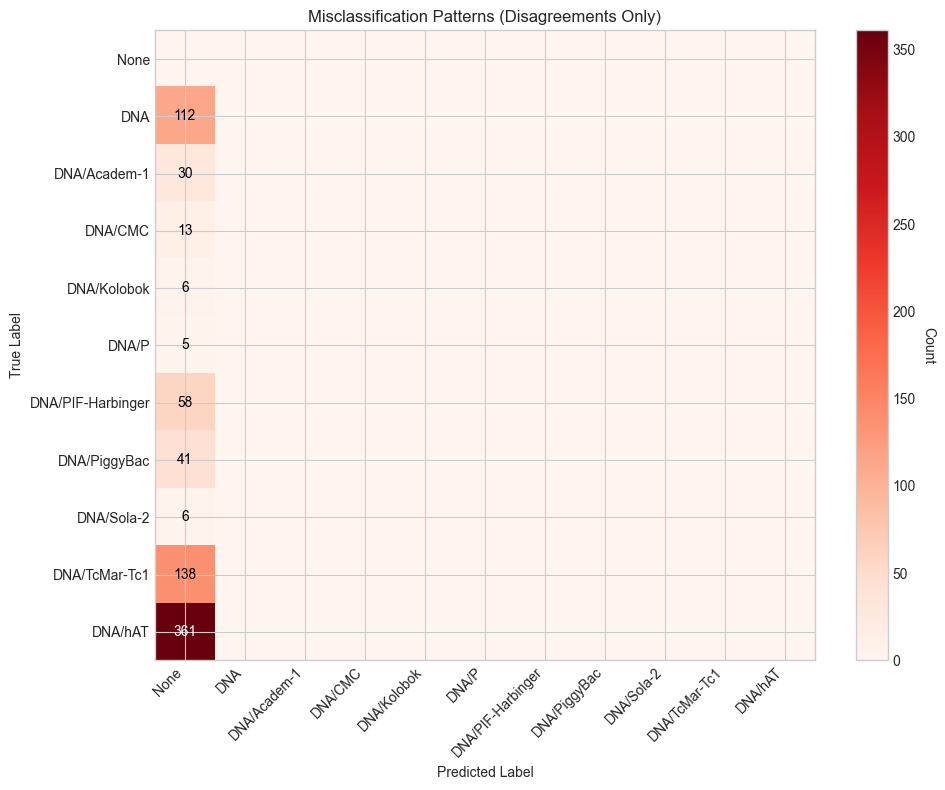

In [15]:
# ============ Visualize Disagreement Patterns ============

def plot_disagreement_heatmap(disagreements_df, class_names):
    """
    Create a heatmap showing misclassification patterns.
    """
    if len(disagreements_df) == 0:
        print("No disagreements to visualize.")
        return None, None
    
    # Create confusion-like matrix for disagreements only
    patterns = disagreements_df.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
    
    # Pivot to matrix form
    matrix = np.zeros((len(class_names), len(class_names)))
    for _, row in patterns.iterrows():
        true_idx = class_names.index(row['true_label']) if row['true_label'] in class_names else -1
        pred_idx = class_names.index(row['pred_label']) if row['pred_label'] in class_names else -1
        if true_idx >= 0 and pred_idx >= 0:
            matrix[true_idx, pred_idx] = row['count']
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(matrix, cmap='Reds', aspect='auto')
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Count', rotation=-90, va="bottom")
    
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    
    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if matrix[i, j] > 0:
                thresh = matrix.max() / 2
                color = 'white' if matrix[i, j] > thresh else 'black'
                ax.text(j, i, int(matrix[i, j]), ha='center', va='center', color=color, fontsize=10)
    
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Misclassification Patterns (Disagreements Only)')
    
    fig.tight_layout()
    return fig, ax

fig, ax = plot_disagreement_heatmap(disagreements, class_names)
if fig:
    plt.show()

## 5. Export Results for Further Analysis

Export the full results dataframe and lists of potentially misclassified sequences.

In [16]:
# ============ Export Results ============

# Create output directory
OUTPUT_DIR = Path("./interpretation_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Export full results
full_results_path = OUTPUT_DIR / "full_predictions.csv"
results_df.to_csv(full_results_path, index=False)
print(f"✓ Saved full results to: {full_results_path}")

# 2. Export disagreements (model prediction != true label)
if len(disagreements) > 0:
    disagreements_path = OUTPUT_DIR / "disagreements.csv"
    disagreements.to_csv(disagreements_path, index=False)
    print(f"✓ Saved disagreements to: {disagreements_path}")

# 3. Export low-confidence predictions
low_conf_path = OUTPUT_DIR / "low_confidence_predictions.csv"
low_conf_df.to_csv(low_conf_path, index=False)
print(f"✓ Saved low-confidence predictions to: {low_conf_path}")

# 4. Export summary statistics
summary = {
    'total_sequences': len(results_df),
    'num_classes': len(class_names),
    'class_names': class_names,
    'accuracy': accuracy_score(true_labels_np, pred_labels_np),
    'balanced_accuracy': balanced_accuracy_score(true_labels_np, pred_labels_np),
    'macro_f1': f1_score(true_labels_np, pred_labels_np, average='macro'),
    'mean_confidence': float(max_probs.mean()),
    'num_disagreements': len(disagreements),
    'disagreement_rate': len(disagreements) / len(results_df),
}

import json
summary_path = OUTPUT_DIR / "summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved summary to: {summary_path}")

print(f"\n📁 All results saved to: {OUTPUT_DIR.resolve()}")

✓ Saved full results to: interpretation_results/full_predictions.csv
✓ Saved disagreements to: interpretation_results/disagreements.csv
✓ Saved low-confidence predictions to: interpretation_results/low_confidence_predictions.csv
✓ Saved summary to: interpretation_results/summary.json

📁 All results saved to: /Users/alexyang/Documents/Part III System Biology/TE Classification/model_result_interp/interpretation_results


## Summary & Recommendations

### What was analyzed:
1. **Confusion Matrix** - Shows how well the model classifies each TE family
2. **Confidence Analysis** - Uses softmax probabilities to measure prediction certainty
3. **Disagreement Detection** - Identifies sequences where model prediction differs from feature-based labels

### Key observations from this run:

⚠️ **The current model appears undertrained** - it predicts nearly everything as "None" class with very low confidence (~0.20, close to uniform distribution over 11 classes).

### To get meaningful results, you need to:

1. **Train the model for more epochs** in `vgp_features_tpase_multiclass.ipynb`:
   - Increase `epochs=3` to at least 50-100
   - Watch for validation macro F1 to improve
   
2. **Check class balancing** - The "None" class has 125k samples vs. a few hundred for other classes
   - Consider upsampling minority classes
   - Use a larger `subset_size` during training
   
3. **Save evaluation data from training notebook**:
   The training notebook should save an `eval_full_dataset.csv` with columns:
   - `header, true_label, pred_label, confidence, prob_class1, prob_class2, ...`
   
   Add this code at the end of training:
   ```python
   # Save evaluation results
   eval_df.to_csv(save_dir + "/eval_full_dataset.csv", index=False)
   ```

### Once properly trained, this notebook will show:
- Which classes are confused with each other
- Low-confidence predictions that may be misclassified
- Sequences where model disagrees with feature-based labels (potential annotation errors)